# 1_data_prep_Barbie
streamlined notebook showing the current routine of grid loading and trimming before we save in the form used for training and testing pitchforks

- duplicated for different grids
- upstream of sandbox files used to test new data augmentations and make plots - do not mess around with grids here!

In [1]:
#misc
import pandas as pd
import numpy as np
import h5py
import random
import time
import os

#plotting
import matplotlib.pyplot as plt
from cmcrameri import cm

## load in the grid:
 - Check headers against BASTA docs here: https://basta.readthedocs.io/en/latest/controls_parameters.html

In [2]:
barbie_h5 = h5py.File("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/Garstec_AS09_barbieMS.hdf5", 'r')

print(list(barbie_h5['grid/tracks/track0001']))

['BP_GAIA', 'FeH', 'FeHini', 'G_GAIA', 'LPhot', 'MMaxNucE', 'Mbcz', 'Mcore', 'McoreX', 'MeH', 'MeHini', 'PS', 'RMaxNucE', 'RP_GAIA', 'Rbcz', 'Rcore', 'RcoreX', 'TAMS', 'Teff', 'ZAMSLPhot', 'ZAMSTeff', 'age', 'alphaFe', 'alphaMLT', 'd02fit', 'd02mean', 'dage', 'dif', 'dnuAsf', 'dnuSer', 'dnufit', 'dnufitMos12', 'dnuscal', 'epsfit', 'epsfitMos12', 'errflagSer', 'eta', 'fdnuAsf', 'fdnuSer', 'gcut', 'logg', 'massfin', 'massini', 'modnum', 'name', 'numax', 'numaxAsf', 'nummodSer', 'osc', 'osckey', 'ove', 'radPhot', 'radTot', 'rho', 'rhocen', 'tau0', 'taubcz', 'tauhe', 'volume_weight', 'xcen', 'xini', 'xsur', 'ycen', 'yini', 'ysur', 'zcen', 'zini', 'zsur']


246


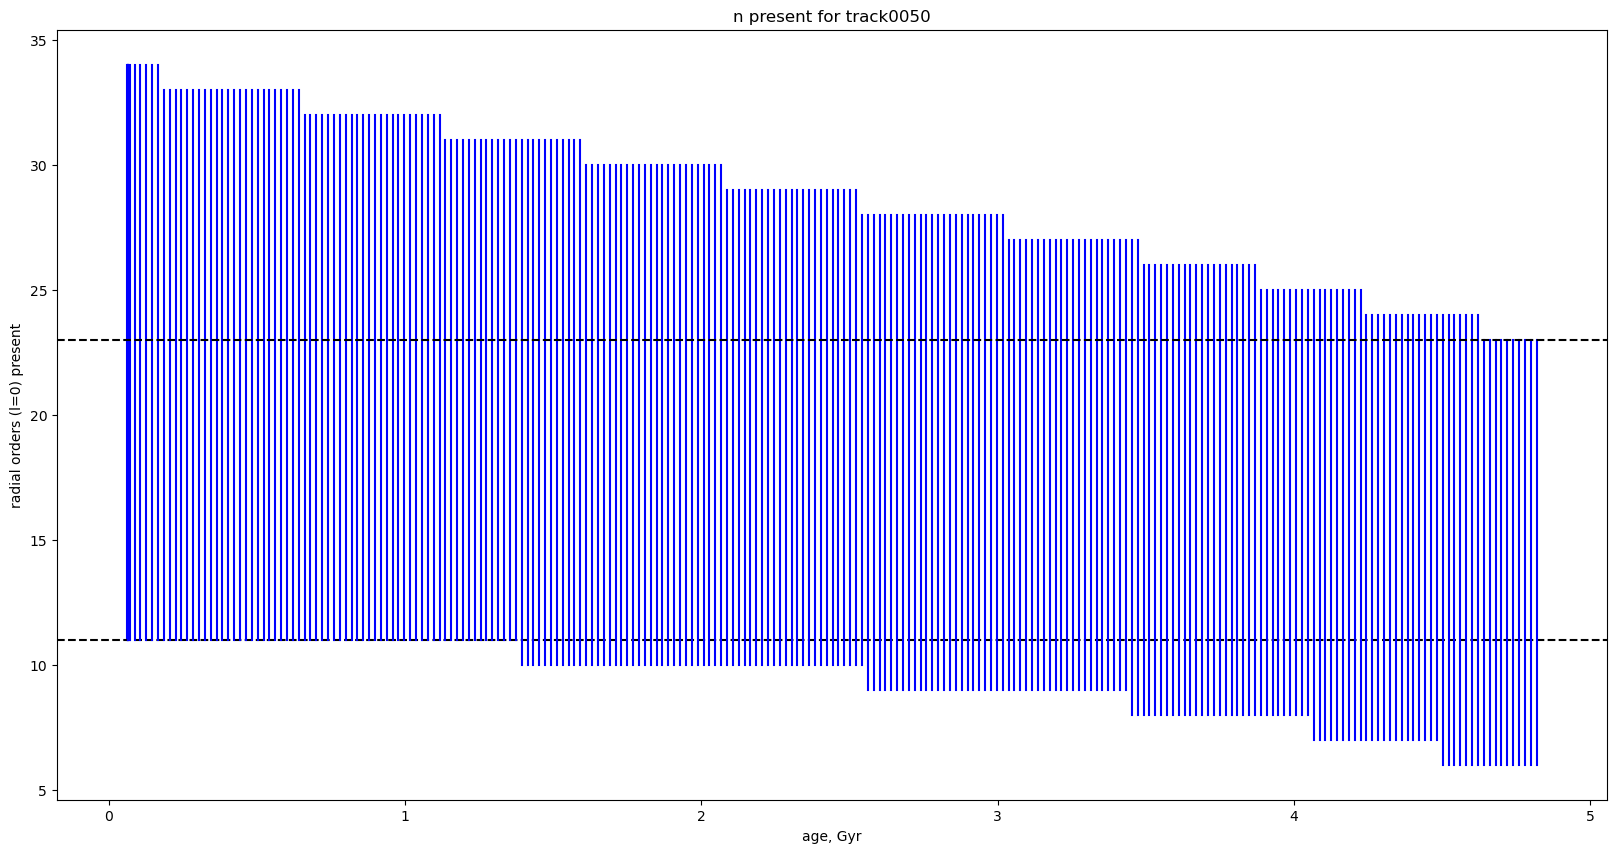

In [6]:
def n_present_plot(grid, track_id, max_age=np.inf):
    plt.figure(figsize=(20,10))
    
    points = np.array(grid['grid/tracks/track'+track_id+'/age'])[np.where(np.array(grid['grid/tracks/track'+track_id+'/age'])<=max_age)[0]]
    first_point = points[0]
    last_point = points[-1]
    
    i = 0
    for point in points:
        osckeys = grid['grid/tracks/track'+track_id+'/osckey']
        n_upper = osckeys[i][1][np.where(osckeys[i][0] == 0)[0][-1]]
        n_lower = osckeys[i][1][np.where(osckeys[i][0] == 0)[0][0]]

        plt.plot(np.full(2,point)/1000, np.array([n_upper, n_lower]), color='blue')
        
        if point == first_point:
            plt.axhline(n_lower, linestyle='dashed', color='black')
        elif point == last_point:
            plt.axhline(n_upper, linestyle='dashed', color='black')
        i+=1

    plt.xlabel('age, Gyr')
    plt.ylabel('radial orders (l=0) present')
    plt.title('n present for track'+track_id)
    print(i)
    
n_present_plot(barbie_h5, '0050')
#print(barbie_h5['grid/tracks/track0001/osckey'][0][1][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])
#print(barbie_h5['grid/tracks/track0001/osc'][0][0][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])

In [5]:
def n_present_plot(grid, track_ids, min_age=0, max_age=np.inf):
    n_lower_max = -np.inf
    n_upper_min = np.inf
    for track_id in track_ids:
        track = grid['grid/tracks/track'+track_id]
        track_age = track['age']
        osckeys = track['osckey']
        
        points = np.array(track_age)[np.where((np.array(track_age)>=min_age) & (np.array(track_age)<=max_age))[0]]
        #points=[points[0], points[-1]]
        i = 0
        osckeys = grid['grid/tracks/track'+track_id+'/osckey']
        for point in points:
            ns = osckeys[i][1][np.where(osckeys[i][0] == 0)]
            n_upper = ns[-1]
            if n_upper < n_upper_min:
                n_upper_min = n_upper
                    
            n_lower = ns[0]
            if n_lower > n_lower_max:
                n_lower_max = n_lower       
            i+=1
        print(track_id, end='\r')
        
    print("lowest n = " + str(n_lower_max))
    print("highest n = " + str(n_upper_min))


track_ids = [track_name.replace('track', '') for track_name in random.sample(list(barbie_h5['grid/tracks']), 1000)]

#track_ids = [track_name.replace('track', '') for track_name in list(barbie_h5['grid/tracks'])]

n_present_plot(barbie_h5, '0800', min_age=1e3, max_age=14e3)
#print(barbie_h5['grid/tracks/track0001/osckey'][0][1][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])
#print(barbie_h5['grid/tracks/track0001/osc'][0][0][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])

KeyError: "Unable to synchronously open object (object 'track0' doesn't exist)"

In [208]:
def n_present_plot(grid, track_ids, min_age=0, max_age=np.inf):
    n_lower_max = -np.inf
    n_upper_min = np.inf
    for track_id in track_ids:
        track = grid['grid/tracks/track'+track_id]
        track_age = track['age']
        osckeys = track['osckey']
        
        points = np.array(track_age)[np.where((np.array(track_age)>=min_age) & (np.array(track_age)<=max_age))[0]]
        #points=[points[0], points[-1]]
        i = 0
        osckeys = grid['grid/tracks/track'+track_id+'/osckey']
        for point in points:
            ns = osckeys[i][1][np.where(osckeys[i][0] == 0)]
            n_upper = ns[-1]
            if n_upper == 0:
                print(track_id)
            if n_upper < n_upper_min:
                n_upper_min = n_upper
                    
            n_lower = ns[0]
            if n_lower > n_lower_max:
                n_lower_max = n_lower       
            i+=1
        #print(track_id, end='\r')
        
    print("lowest n = " + str(n_lower_max))
    print("highest n = " + str(n_upper_min))

track_ids = [track_name.replace('track', '') for track_name in list(barbie_h5['grid/tracks'])]
track_ids.remove('2221')
track_ids.remove('5671')

n_present_plot(barbie_h5, track_ids, max_age=14e3)
#print(barbie_h5['grid/tracks/track0001/osckey'][0][1][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])
#print(barbie_h5['grid/tracks/track0001/osc'][0][0][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])

KeyboardInterrupt: 

In [211]:
track_ids = [track_name.replace('track', '') for track_name in list(barbie_h5['grid/tracks'])]
count = 0

track_file = barbie_h5['grid/tracks']
for track_id in track_ids:
    track = track_file['track'+track_id]
    count+= len(list(track['age']))
    print(count, end='\r')

In [178]:
i=0
for osckey in list(barbie_h5['grid/tracks/track2221/osckey']):
    osckeys = osckey[1][np.where(osckey[0] == 0)]
    if min(osckeys) == 0:
        print(i, osckeys)
    i+=1



33 [0]


In [11]:
list(barbie_h5['grid/tracks/track2221/dnufit'])[33]

0.0

In [182]:
i=0
for osckey in list(barbie_h5['grid/tracks/track5671/osckey']):
    osckeys = osckey[1][np.where(osckey[0] == 0)]
    if min(osckeys) == 0:
        print(i, osckeys)
    i+=1



6 [0]


In [186]:
list(barbie_h5['grid/tracks/track5671/osckey'])[6]

array([array([-1,  0]), array([-1,  0])], dtype=object)

In [217]:
def track_df_gen(grid, track_ids, headers):
    
    i=0
    for track_id in track_ids:
        track = grid['grid/tracks/track'+track_id]
        
        track_array = np.full(len(track[headers[0]]), int(track_id))

        for header in headers:
            track_array = np.column_stack((track_array, np.array(track[header])))
            
        if i == 0:
            tracks_array = track_array
            i=1
        else:
            tracks_array = np.vstack((tracks_array, track_array))

    return pd.DataFrame(tracks_array, columns = ['track_id']+headers)
    
headers = ['age', 'Teff', 'LPhot']

track_ids = [track_name.replace('track', '') for track_name in random.sample(list(barbie_h5['grid/tracks']), 100)]

tracks_df = track_df_gen(barbie_h5,track_ids, headers)

## data prep:

### pre prep plots

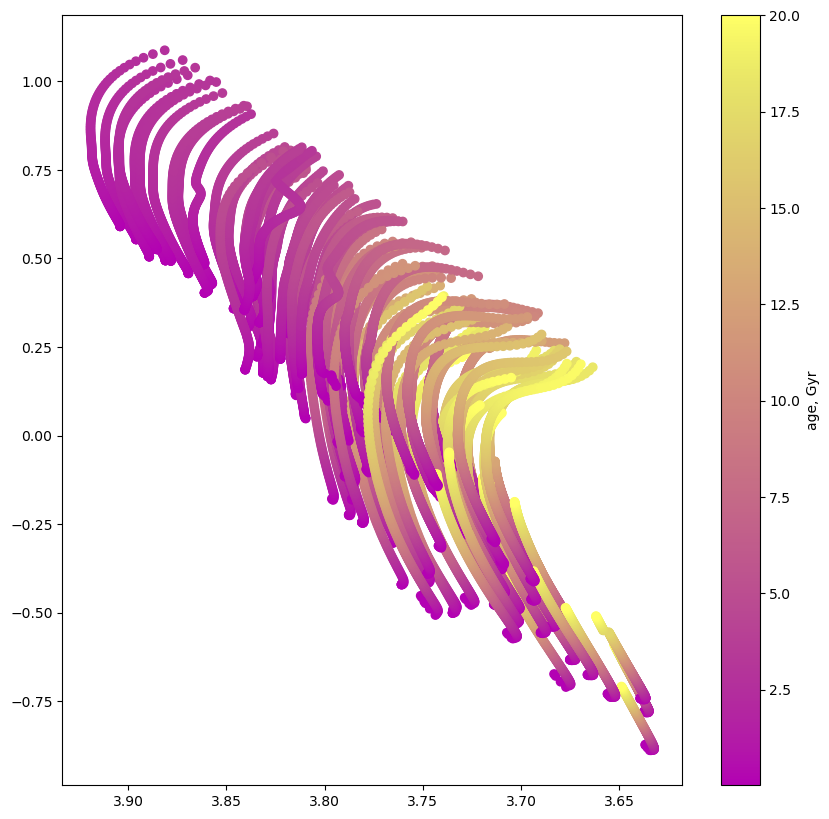

In [220]:
headers = ['age', 'Teff', 'LPhot']
track_ids = [track_name.replace('track', '') for track_name in random.sample(list(barbie_h5['grid/tracks']), 100)]

tracks_df = track_df_gen(barbie_h5,track_ids,headers)

plt.figure(figsize=(10,10))
plt.scatter(np.log10(tracks_df['Teff']), np.log10(tracks_df['LPhot']), c=tracks_df['age']/1000, cmap=cm.buda)
plt.xlabel

cbar = plt.colorbar()
cbar.set_label('age, Gyr')

plt.gca().invert_xaxis()

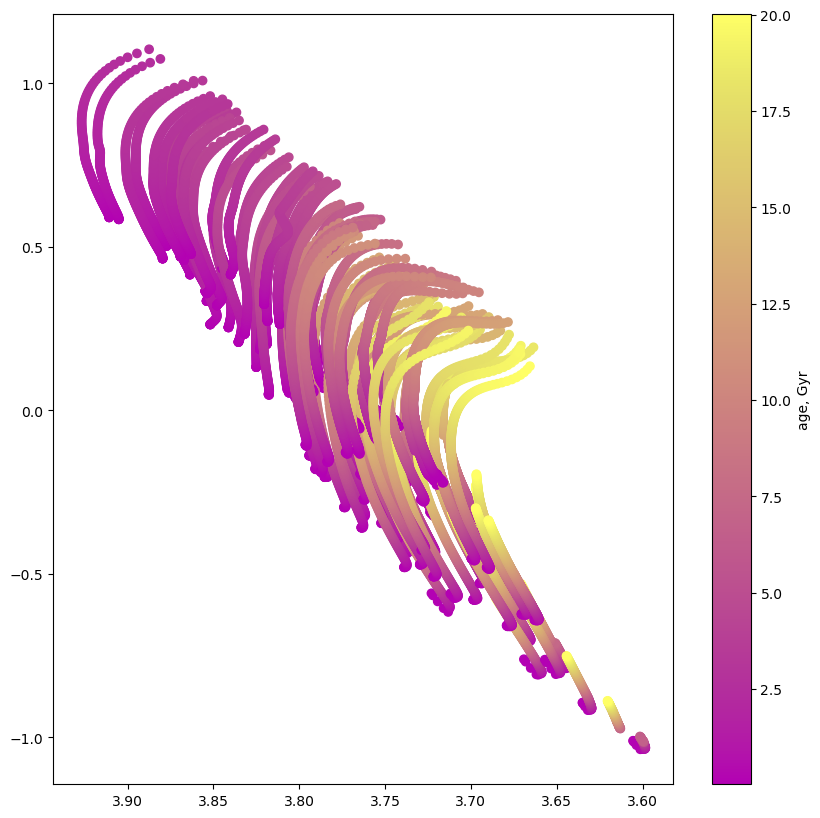

In [8]:
def track_df_gen(grid, track_ids, headers=['age', 'Teff', 'LPhot']):
    
    i=0
    for track_id in track_ids:
        track = grid['grid/tracks/track'+track_id]
        
        track_array = np.full(len(track[headers[0]]), int(track_id))

        for header in headers:
            track_array = np.column_stack((track_array, np.array(track[header])))
            
        if i == 0:
            tracks_array = track_array
            i=1
        else:
            tracks_array = np.vstack((tracks_array, track_array))

    return pd.DataFrame(tracks_array, columns = ['track_id']+headers)
    
    
track_ids = [track_name.replace('track', '') for track_name in random.sample(list(barbie_h5['grid/tracks']), 100)]

tracks_df = track_df_gen(barbie_h5,track_ids)

plt.figure(figsize=(10,10))
plt.scatter(np.log10(tracks_df['Teff']), np.log10(tracks_df['LPhot']), c=tracks_df['age']/1000, cmap=cm.buda)
plt.xlabel

cbar = plt.colorbar()
cbar.set_label('age, Gyr')

plt.gca().invert_xaxis()